# KNN Classification Baseline

**Project question:** Can nearby standardized customer profiles predict a binary high-value label?

By the end of this notebook, you should be able to:

- tune K using cross-validation restricted to training data
- compare KNN with a class-prior baseline and logistic regression
- report final test accuracy, balanced accuracy, and ROC-AUC

This notebook is a demonstration, not a homework assignment. The data are
synthetic and were generated for teaching; numerical results should not be
interpreted as evidence about a real organization or population.

In [1]:

from lite_setup import ensure_packages
await ensure_packages()

Using the current Python environment.


In [2]:

import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("data")
if not DATA.exists():
    raise FileNotFoundError("Open this notebook from the JupyterLite files root so data/ is available.")

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score

In [4]:
df = pd.read_csv(DATA / 'simulated_customer_profiles.csv')
features = ['visits_per_month', 'avg_order_value', 'discount_rate', 'email_opens', 'tenure_months', 'support_contacts', 'returns_per_year']
X = df[features]
y = df['high_value']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.25, random_state=4031
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=4031)
y.value_counts(normalize=True).rename('proportion')

high_value
0    0.659259
1    0.340741
Name: proportion, dtype: float64

In [5]:
rows = []
for k in range(1, 22, 2):
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    scores = cross_val_score(model, X_train, y_train, scoring='balanced_accuracy', cv=cv)
    rows.append({
        'k': k,
        'cv_balanced_accuracy_mean': scores.mean(),
        'cv_balanced_accuracy_sd': scores.std(ddof=1),
    })
results = pd.DataFrame(rows)
best_k = int(results.loc[results['cv_balanced_accuracy_mean'].idxmax(), 'k'])
results

,k,cv_balanced_accuracy_mean,cv_balanced_accuracy_sd
0,1,0.988604,0.017124
1,3,0.989153,0.016048
2,5,0.982011,0.025488
3,7,0.982011,0.025488
4,9,0.982011,0.025488
5,11,0.982011,0.025488
6,13,0.982011,0.025488
7,15,0.982011,0.025488
8,17,0.982011,0.025488
9,19,0.982011,0.025488


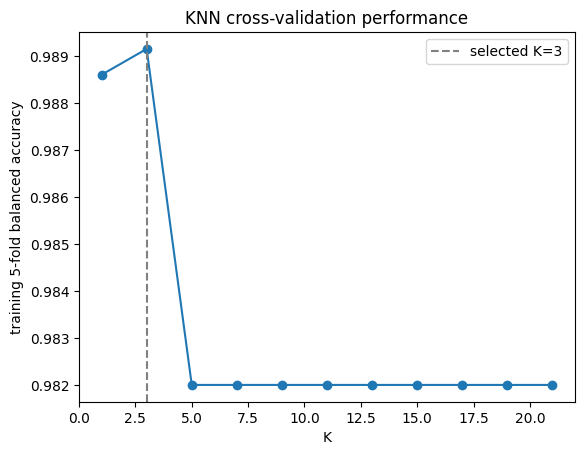

In [6]:
plt.plot(results['k'], results['cv_balanced_accuracy_mean'], marker='o')
plt.axvline(best_k, color='gray', linestyle='--', label=f'selected K={best_k}')
plt.xlabel('K')
plt.ylabel('training 5-fold balanced accuracy')
plt.title('KNN cross-validation performance')
plt.legend()

Small K can have high variance; large K can smooth away local structure. K is selected on training folds only. Balanced accuracy gives equal weight to sensitivity in each class.

In [7]:
models = {
    'class-prior baseline': DummyClassifier(strategy='prior'),
    'logistic regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=4031)),
    'tuned KNN': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k)),
}
rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    probability = model.predict_proba(X_test)[:, 1]
    rows.append({
        'model': name,
        'test_accuracy': accuracy_score(y_test, prediction),
        'test_balanced_accuracy': balanced_accuracy_score(y_test, prediction),
        'test_roc_auc': roc_auc_score(y_test, probability),
    })
pd.DataFrame(rows).sort_values('test_balanced_accuracy', ascending=False)

,model,test_accuracy,test_balanced_accuracy,test_roc_auc
1,logistic regression,0.985294,0.978261,1.0
2,tuned KNN,0.985294,0.978261,1.0
0,class-prior baseline,0.661765,0.500000,0.5


**Interpretation:** KNN is a useful nonlinear baseline only when the chosen features and distance represent meaningful similarity. A strong logistic comparator may be preferable when performance is similar and coefficient-based communication matters.